In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from probjax.nn.layers.attention import flex_attention, dot_product_attention, BlockSizes
from probjax.nn.nets import Transformer
from probjax.utils.bmutil import benchmark
import jax.numpy as jnp
import jax

from flax import nnx
from functools import partial
from probjax.utils.bmutil import benchmark

from probjax.nn.pallas_kernels.flash_attention import flash_attention
from probjax.nn.pallas_kernels.attention import mha

/Users/manug/src/probjax/probjax/utils/bmutil.py:6: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  from pynvml import (


In [18]:
import jax
import jax.numpy as jnp
seq_len = 256
q = jax.random.normal(jax.random.PRNGKey(0), (1,seq_len, 8, 64), dtype=jnp.bfloat16)
k = jax.random.normal(jax.random.PRNGKey(1), (1,seq_len, 8, 64), dtype=jnp.bfloat16)
v = jax.random.normal(jax.random.PRNGKey(2), (1,seq_len, 8, 64), dtype=jnp.bfloat16)

In [4]:
attn_fn = jax.jit(partial(dot_product_attention, dtype=jnp.float32))
out1 = attn_fn(q.astype(jnp.float32), k.astype(jnp.float32), v.astype(jnp.float32))

In [5]:
_ = benchmark(attn_fn, q, k, v)

CPU Utilization: 39% +/- 5%
Memory Utilization: 2% +/- 0%
Average time taken: 1.07 ms


In [6]:
import math
attn_fn = jax.jit(partial(flex_attention, sm_scale=1. / math.sqrt(64)))
out2 = attn_fn(q,k,v)

(1, 256, 8, 64) (1, 256, 8, 64) (1, 256, 8, 64)
(1, 256, 8, 64) (1, 256, 8, 64) (1, 256, 8, 64)


ValueError: The precision 'BF16_BF16_BF16' is not supported by dot_general on CPU

In [6]:
import math
out3 = flash_attention(q, k, v, softmax_scale=1/math.sqrt(64))

ValueError: Only interpret mode is supported on CPU backend.

In [5]:
_ = benchmark(attn_fn, q, k, v)

CPU Utilization: 55% +/- 4%
Memory Utilization: 1% +/- 0%
Average time taken: 2.78 ms


In [7]:
jnp.mean(jnp.abs(out1 - out2))

NameError: name 'out2' is not defined

In [10]:
jnp.mean(jnp.abs(out1 - out3))

Array(0., dtype=float32)

jnp.allclose(out1, out2, atol=1e-1, rtol=1e-1)

mask_q: (Array(256, dtype=int32, weak_type=True),)


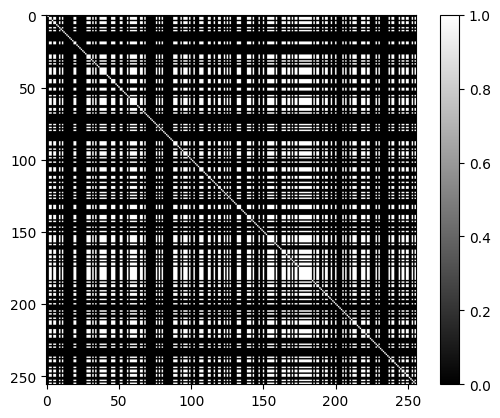

In [45]:
import matplotlib.pyplot as plt
from probjax.nn.pallas_kernels.attention_mask_bias import CausalMask, materialize_mask, LocalWindowMask, SameSegmentMask, KeyPaddingMask, QKVLengthMask, MarginalizationMask

mask = CausalMask()
mask = LocalWindowMask(32,32)
segment_id = jnp.arange(seq_len)
mask = SameSegmentMask(segment_id, segment_id[::-1])
mask = KeyPaddingMask(jnp.array([256]*256 + [64]*128 + [32]*128))
mask = QKVLengthMask(q_length=210, kv_length=210)
mask = jax.random.bernoulli(jax.random.PRNGKey(0), p=0.5, shape=(seq_len,))
mask = MarginalizationMask(mask)

plt.imshow(materialize_mask(mask, 256, 256), cmap='gray', vmin=0, vmax=1)
plt.colorbar()


In [46]:
mask.get_data()

(Array([False, False,  True,  True, False,  True,  True, False, False,
         True, False,  True, False, False, False, False, False, False,
        False,  True,  True, False, False, False, False, False, False,
        False,  True,  True,  True, False,  True, False,  True, False,
        False,  True,  True,  True,  True,  True, False, False, False,
         True,  True,  True, False, False, False,  True,  True, False,
        False, False,  True, False,  True,  True,  True,  True,  True,
        False, False,  True,  True, False,  True, False, False, False,
        False, False, False, False,  True, False,  True, False,  True,
        False, False, False, False, False, False, False,  True,  True,
         True, False, False,  True, False,  True,  True,  True, False,
         True, False, False,  True, False, False, False,  True,  True,
         True, False, False, False,  True,  True, False, False,  True,
        False, False,  True,  True, False, False,  True, False,  True,
      

In [47]:
q.shape

(1, 256, 8, 64)

In [48]:
import math
out1 = dot_product_attention(q.astype(jnp.float32),k.astype(jnp.float32),v.astype(jnp.float32), mask=materialize_mask(mask,seq_len, seq_len))
out2 = flex_attention(q.astype(jnp.float32),k.astype(jnp.float32),v.astype(jnp.float32), mask=mask)
#out2 = flash_attention(q, k, v, mask_fn=lambda x,y: y > 50, softmax_scale=1/math.sqrt(64), interpret=True)

jnp.mean(jnp.abs(out1 - out2))


mask_q: (Array(256, dtype=int32, weak_type=True),)
(1, 256, 8, 64) (1, 256, 8, 64) (1, 256, 8, 64)
(1, 256, 8, 64) (1, 256, 8, 64) (1, 256, 8, 64)
mask_q: (Array(128, dtype=int32),)
mask_q: (Array(128, dtype=int32),)
mask_q: (Array(128, dtype=int32),)
mask_q: (Array(128, dtype=int32),)
mask_q: (Array(128, dtype=int32),)
mask_q: (Array(128, dtype=int32),)
mask_q: (Array(128, dtype=int32),)
mask_q: (Array(128, dtype=int32),)
mask_q: (Array(128, dtype=int32),)
mask_q: (Array(128, dtype=int32),)
mask_q: (Array(128, dtype=int32),)
mask_q: (Array(128, dtype=int32),)
mask_q: (Array(128, dtype=int32),)
mask_q: (Array(128, dtype=int32),)
mask_q: (Array(128, dtype=int32),)
mask_q: (Array(128, dtype=int32),)
mask_q: (Array(128, dtype=int32),)
mask_q: (Array(128, dtype=int32),)
mask_q: (Array(128, dtype=int32),)
mask_q: (Array(128, dtype=int32),)
mask_q: (Array(128, dtype=int32),)
mask_q: (Array(128, dtype=int32),)
mask_q: (Array(128, dtype=int32),)
mask_q: (Array(128, dtype=int32),)
mask_q: (Arra

Array(0., dtype=float32)

In [114]:
segment_id.shape

(256,)

In [17]:
from functools import partial


_ = benchmark(attn_fn, q, k, v)

NameError: name 'attn_fn' is not defined

In [12]:
attn_fn = jax.jit(partial(flex_attention, mask=LocalWindowMask(32,32)))
_ = benchmark(attn_fn, q, k, v)

CPU Utilization: 32% +/- 2%
Memory Utilization: 4% +/- 0%
Average time taken: 216.02 ms


In [11]:
attn

NameError: name 'attn' is not defined

In [ ]:
attn_fn = jax.jit(dot_product_attention)
out3 = attn_fn(q, k, v)

In [ ]:
attn_fn = jax.jit(partial(flex_attention, sm_scale=1.))
out = attn_fn(q, k, v)

In [ ]:
attn_fn = jax.jit(partial(flash_attention, mask_fn=lambda q_id, k_id: jnp.abs(q_id - k_id) <= 32, interpret=True))
_ = benchmark(attn_fn, q.astype(jnp.float32), k.astype(jnp.float32), v.astype(jnp.float32))

CPU Utilization: 73% +/- 5%
Memory Utilization: 4% +/- 0%
Average time taken: 311.61 ms


In [ ]:
attn_fn = jax.jit(flash_attention)
out2 = attn_fn(q, k, v)

In [ ]:
out2 = attn_fn(q, k, v)

In [ ]:
out - out2

Array([[[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0.000976562, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        ...,

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0.000244141, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0,

In [ ]:
_ = benchmark(attn_fn, q, k, v)

GPU Utilization: 40% +/- 7%,GPU Memory Utilization: 0% +/- 0% 
CPU Utilization: 2% +/- 1%
Memory Utilization: 0% +/- 0%
Average time taken: 77.48 us


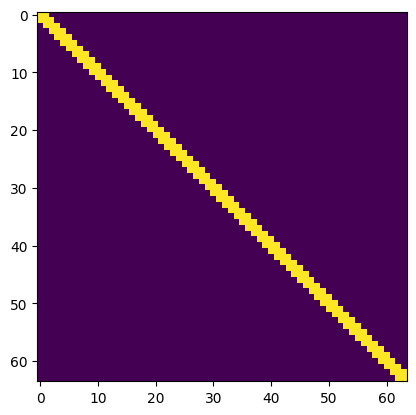

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(build_mask(lambda q_id, k_id: jnp.abs(q_id - k_id) < 32, q_seq_len=2048,kv_seq_len=2048, block_q=32, block_k=32))

In [ ]:
from probjax.nn.pallas_kernels.flash_attention import query_iterator_indices
blockmask = build_mask(lambda q_id, k_id: jnp.abs(q_id - k_id) < 2, q_seq_len=2048,kv_seq_len=2048, block_q=64, block_k=64)
q_id, k_id = query_iterator_indices(blockmask)

In [ ]:

blockmask[0]

array([ True,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False])

In [ ]:
q_id[9]

Array([ 8,  9, 10,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],      dtype=int32)

In [ ]:
k_id

Array([2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 2], dtype=int32)

In [ ]:
attn_fn = jax.jit(partial(flex_attention, num_stages=3, window_size=(-32,32)))

In [ ]:
attn_fn = jax.jit(flex_attention)

In [ ]:
attn_fn = jax.jit(partial(flash_attention, mask_fn=lambda q_id, k_id: jnp.abs(q_id - k_id) <= 32, block_q=64, block_k=64))
#attn_fn = jax.jit(flash_attention)

In [ ]:
def f(q):
    q = q.repeat(16, axis=-2)
    q = q.repeat(64, axis=-1)
    return attn_fn(q,q,q).sum(axis=(-2,-1))


f_grad_jit = jax.jit(jax.grad(f))

In [ ]:
J = jax.jacobian(f)(q[:,:128,:1, :1])

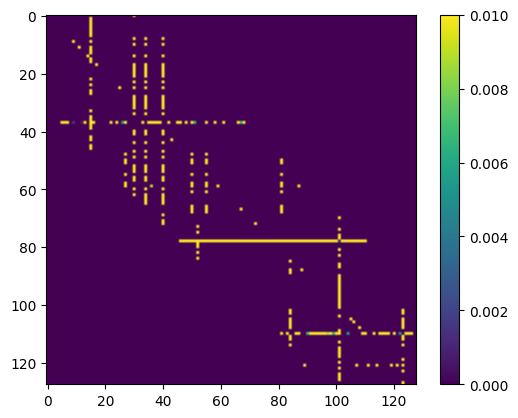

In [ ]:
plt.imshow(J.reshape((128,128)),vmin=0,vmax=.01)
plt.colorbar()

In [ ]:
%%timeit
f_grad_jit(q).block_until_ready()

TypeError: Gradient only defined for scalar-output functions. Output had shape: (1, 2048).

In [ ]:
def f(q):
    return attn_fn(q,q.repeat(2, axis=1),q.repeat(2, axis=1)).sum()


f_grad_jit = jax.jit(jax.grad(f))

In [ ]:
%%timeit
f_grad_jit(q).block_until_ready()

6.58 ms ± 21.1 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
